In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

print(torch.__version__)

2.10.0+cpu


In [2]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 49.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.62MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 40)  # 20 for mean, 20 for log variance
        )
        self.decoder = nn.Sequential(
            nn.Linear(20, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = h[:, :20], h[:, 20:]
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

def vae_loss(recon_x, x, mu, log_var):
    bce_loss = nn.functional.binary_cross_entropy(recon_x, (x + 1) / 2, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce_loss + kl_loss

In [4]:
num_epochs = 10  # Adjust based on training time constraints
for epoch in range(num_epochs):
    for images, _ in trainloader:
        images = images.view(images.size(0), -1).to(device)
        optimizer.zero_grad()
        recon_images, mu, log_var = vae(images.to(device))
        loss = vae_loss(recon_images, images, mu, log_var)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 50041.0039
Epoch 2, Loss: 50045.8633
Epoch 3, Loss: 49817.9102
Epoch 4, Loss: 49597.0156
Epoch 5, Loss: 49524.9609
Epoch 6, Loss: 49436.8555
Epoch 7, Loss: 49571.7578
Epoch 8, Loss: 49233.4961
Epoch 9, Loss: 49281.9180
Epoch 10, Loss: 49589.3008


In [5]:
vae.eval()
z = torch.randn(16, 20).to(device)  # Sample from the learned latent space
with torch.no_grad():
    generated_images = vae.decoder(z).view(-1, 1, 28, 28)

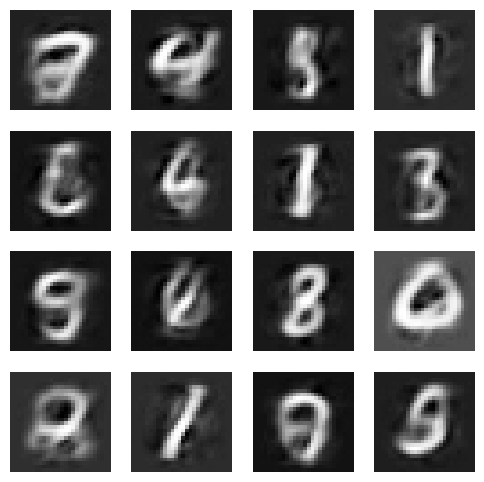

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.show()
